# Chapter 2: Pytorch Classification

# 1: Making, Converting into Tensor & spliting data into test and train

Making some (Toy dataset): dataset small enough to experiment but still sizable enough to practice the fundamentals **bold text**

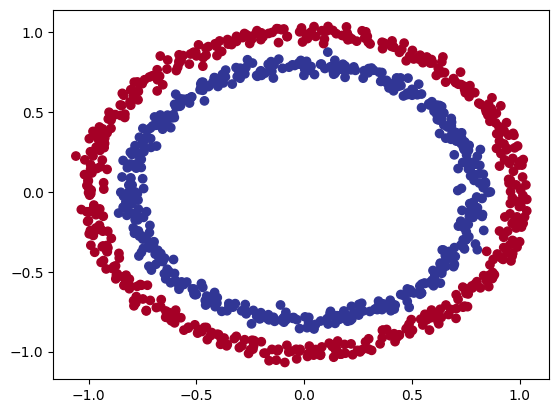

In [41]:
from sklearn.datasets import make_circles
import pandas as pd
import matplotlib.pyplot as plt

n_samples = 1000

X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state = 42)

# print(f"Datas: {X[:5]} \n Labels: {Y[:5]}")

data = pd.DataFrame(
    {"X1": X[:, 0],
     "X2": X[:, 1],
     "Labels" : y}
)
data.head(7)

plt.scatter(x = X[:, 0],
            y = X[:, 1],
            c=y,
            cmap = plt.cm.RdYlBu)
plt.show()

In [42]:
X.shape, y.shape

((1000, 2), (1000,))

Checking the shape and size of data

In [43]:
X_sample = X[0]
y_sample = y[0]

print(f"the X_sample is: {X_sample} & y_sampel is: {y_sample}")
print(f"the shape of X_sample is: {X_sample.shape} & y_sampel is: {y_sample.shape}")


the X_sample is: [0.75424625 0.23148074] & y_sampel is: 1
the shape of X_sample is: (2,) & y_sampel is: ()


Converting data into tensor

In [44]:
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float32)
Y = torch.from_numpy(y).type(torch.float32)

X[:5], Y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

Spliting train and test data

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    Y,
                                                    test_size=0.2,
                                                    random_state=42)
# X_train[:5], X_test[:5], y_train[:5], y_test[:5]
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

**Agnostic code**

In [46]:
from torch import nn
device = "cuda" if torch.cuda.is_available() else 'cpu'
device

'cuda'

#2: Build Model
1) Subclasses nn.Module (almost all PyTorch models are subclasses of nn.Module).
2) Creates 2 nn.Linear layers in the constructor capable of handling the input and output shapes of X and y.
3) Defines a forward() method containing the forward pass computation of the model.
5) Instantiates the model class and sends it to the target device.

In [47]:
class circlesModelv0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  def forward(self, x):
    return self.layer_2(self.layer_1(x))
model_0  = circlesModelv0().to(device)
model_0

circlesModelv0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [48]:
# Duplicating the above module with nn.Sequential
# model_00 = nn.Sequential(
#     nn.Linear(in_features=2, out_features=5),
#     nn.Linear(in_features=5, out_features=1)
# )
# model_00

In [49]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]], device='cuda:0')),
             ('layer_1.bias',
              tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]], device='cuda:0')),
             ('layer_2.bias', tensor([-0.2060], device='cuda:0'))])

2.1) Setting up loos and optimizer function
Here,
loos fn: nn.BCEWithLogitsLoss() <- sigmoid() is in-built

optimizer: torch.optim.SGD()

In [50]:
loos = nn.BCEWithLogitsLoss()
optimzer = torch.optim.SGD(params = model_0.parameters(),
                           lr = 0.1)
def acuracy(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  accuracy = ((correct / len(y_pred)) * 100 )
  return accuracy

# 3: Train the model

1) Forward pass - The model goes through all of the training data once, performing its forward() function calculations (model(x_train)).

2) Calculate the loss - The model's outputs (predictions) are compared to the ground truth and evaluated to see how wrong they are (loss = loss_fn(y_pred, y_train).

3) Zero gradients - The optimizers gradients are set to zero (they are accumulated by default) so they can be recalculated for the specific training step (optimizer.zero_grad()).

4) Perform backpropagation on the loss - Computes the gradient of the loss with respect for every model parameter to be updated (each parameter with requires_grad=True). This is known as backpropagation, hence "backwards" (loss.backward()).

5) Step the optimizer (gradient descent) - Update the parameters with requires_grad=True with respect to the loss gradients in order to improve them (optimizer.step()).

In [51]:
# Re-instantiate model_0 to pick up the corrected class definition
model_0 = circlesModelv0().to(device)

with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
# print(y_logits)

y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

y_predes = torch.round(y_pred_probs)
y_predes

y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))
y_pred_labels

print(torch.eq(y_predes.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_predes.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 1., 0., 1.], device='cuda:0')

3.1) Training and testing loop

In [52]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  ## Traing
  model_0.train()

  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loos(y_logits, # Using nn.BCEWithLogitsLoss works with raw logits
                   y_train)
  acc = acuracy(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
  optimzer.zero_grad()

    # 4. Loss backwards
  loss.backward()

    # 5. Optimizer step
  optimzer.step()

    ### Testing
  model_0.eval()
  with torch.inference_mode():
        # 1. Forward pass
      test_logits = model_0(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
      test_loss = loos(test_logits,
                            y_test)
      test_acc = acuracy(y_true=y_test,
                               y_pred=test_pred)

    # Print out what's happening every 10 epochs
  if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")
# a = test_logits[:5] #<------------------------------------------------------------------------------------------------------------------------

Epoch: 0 | Loss: 0.69796, Accuracy: 51.88% | Test loss: 0.69462, Test acc: 57.50%
Epoch: 100 | Loss: 0.69796, Accuracy: 51.88% | Test loss: 0.69462, Test acc: 57.50%
Epoch: 200 | Loss: 0.69796, Accuracy: 51.88% | Test loss: 0.69462, Test acc: 57.50%
Epoch: 300 | Loss: 0.69796, Accuracy: 51.88% | Test loss: 0.69462, Test acc: 57.50%
Epoch: 400 | Loss: 0.69796, Accuracy: 51.88% | Test loss: 0.69462, Test acc: 57.50%
Epoch: 500 | Loss: 0.69796, Accuracy: 51.88% | Test loss: 0.69462, Test acc: 57.50%
Epoch: 600 | Loss: 0.69796, Accuracy: 51.88% | Test loss: 0.69462, Test acc: 57.50%
Epoch: 700 | Loss: 0.69796, Accuracy: 51.88% | Test loss: 0.69462, Test acc: 57.50%
Epoch: 800 | Loss: 0.69796, Accuracy: 51.88% | Test loss: 0.69462, Test acc: 57.50%
Epoch: 900 | Loss: 0.69796, Accuracy: 51.88% | Test loss: 0.69462, Test acc: 57.50%


# 4: Make prediction and Evaluating and Model(Vizualizing the data)

Downloading the "helper_functions", and using the important function

In [53]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


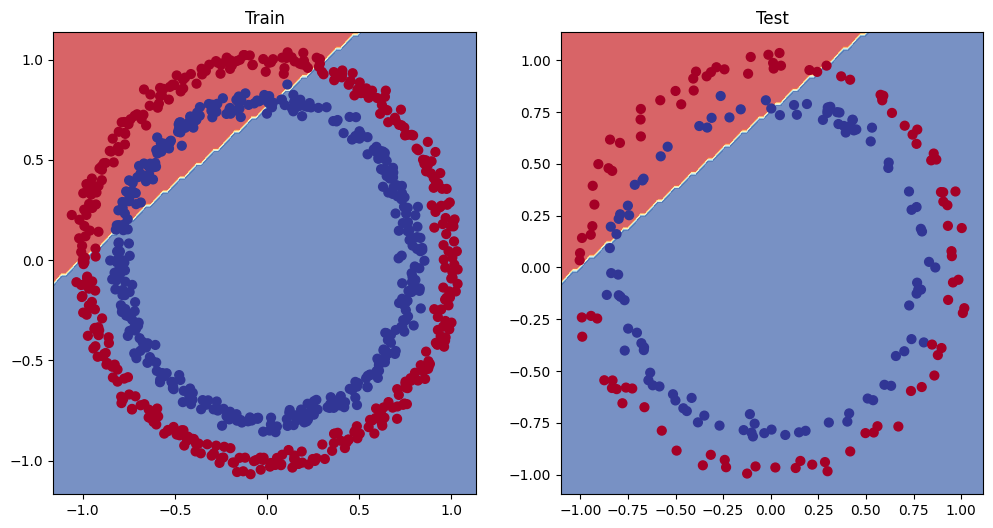

In [54]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

# 5: Improving Model

Improving the model by:
1) Adding more layer
2) adding more hiden units
3) increasing the epochs

In [55]:
class circlesModelv1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features= 10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = circlesModelv1().to(device)
# model_1.state_dict()

In [56]:
# Loss_fn
loss = nn.BCEWithLogitsLoss()

#optimizer_fn
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr = 0.1)



In [57]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  ## Traing
  model_1.train()

  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loos(y_logits, # Using nn.BCEWithLogitsLoss works with raw logits
                   y_train)
  acc = acuracy(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
  optimzer.zero_grad()

    # 4. Loss backwards
  loss.backward()

    # 5. Optimizer step
  optimzer.step()

    ### Testing
  model_0.eval()
  with torch.inference_mode():
        # 1. Forward pass
      test_logits = model_1(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
      test_loss = loos(test_logits,
                            y_test)
      test_acc = acuracy(y_true=y_test,
                               y_pred=test_pred)

    # Print out what's happening every 10 epochs
  if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 100 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 200 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 300 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 400 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 500 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 600 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 700 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 800 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 900 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%


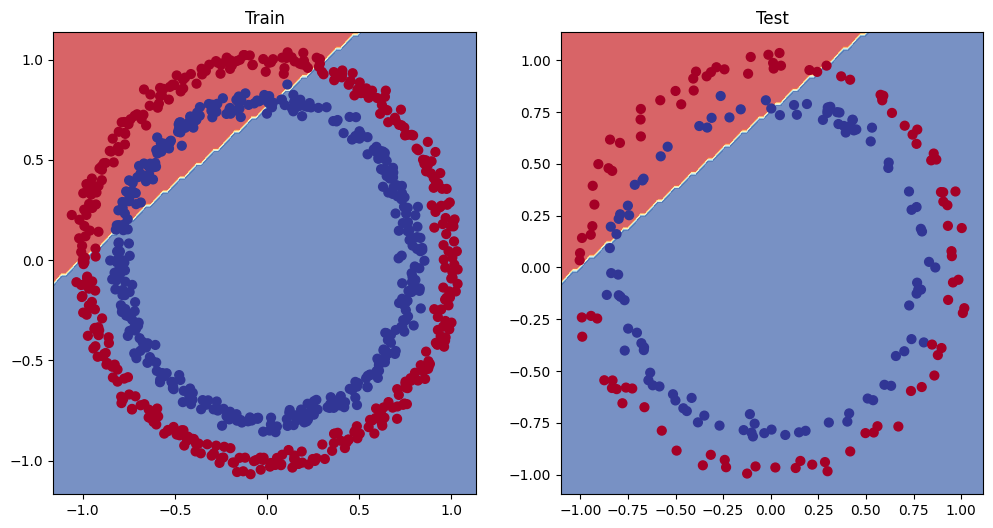

In [58]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

5.1 Preparing data to see if our model can model a straight line

In [59]:
# Create some data (same as notebook 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias # linear regression formula

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [60]:
# Create train and test splits
train_split = int(0.8 * len(X_regression)) # 80% of data used for training set
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Check the lengths of each split
print(len(X_train_regression),
    len(y_train_regression),
    len(X_test_regression),
    len(y_test_regression))

80 80 20 20


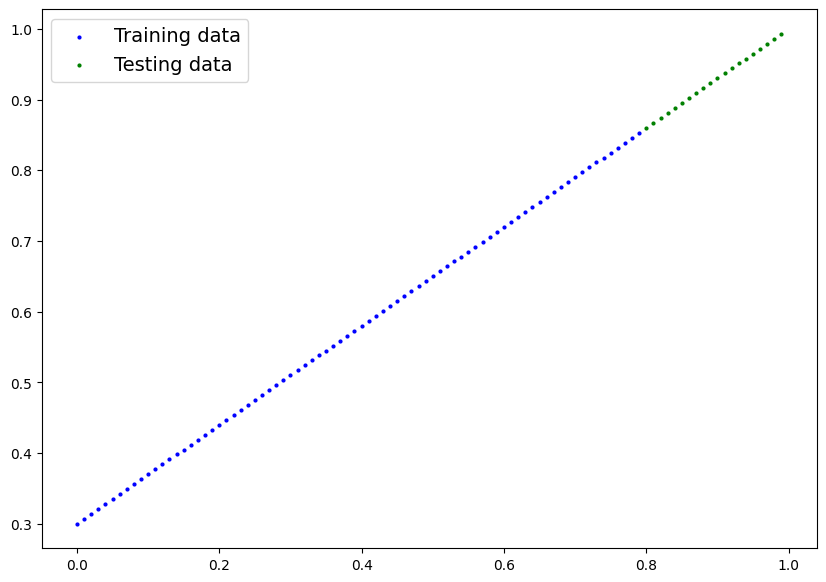

In [61]:
plot_predictions(train_data=X_train_regression,
    train_labels=y_train_regression,
    test_data=X_test_regression,
    test_labels=y_test_regression
);

5.2 Adjusting model_1 to fit a straight line

In [62]:
# Same architecture as model_1 (but using nn.Sequential)
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [63]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)

In [64]:
# Train the model
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data to target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    ### Training
    # 1. Forward pass
    y_pred = model_2(X_train_regression)

    # 2. Calculate loss (no accuracy since it's a regression problem, not classification)
    loss = loss_fn(y_pred, y_train_regression)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_pred = model_2(X_test_regression)
      # 2. Calculate the loss
      test_loss = loss_fn(test_pred, y_test_regression)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")

Epoch: 0 | Train loss: 0.75986, Test loss: 0.54143
Epoch: 100 | Train loss: 0.09309, Test loss: 0.02901
Epoch: 200 | Train loss: 0.07376, Test loss: 0.02850
Epoch: 300 | Train loss: 0.06745, Test loss: 0.00615
Epoch: 400 | Train loss: 0.06107, Test loss: 0.02004
Epoch: 500 | Train loss: 0.05698, Test loss: 0.01061
Epoch: 600 | Train loss: 0.04857, Test loss: 0.01326
Epoch: 700 | Train loss: 0.06109, Test loss: 0.02127
Epoch: 800 | Train loss: 0.05599, Test loss: 0.01426
Epoch: 900 | Train loss: 0.05571, Test loss: 0.00603


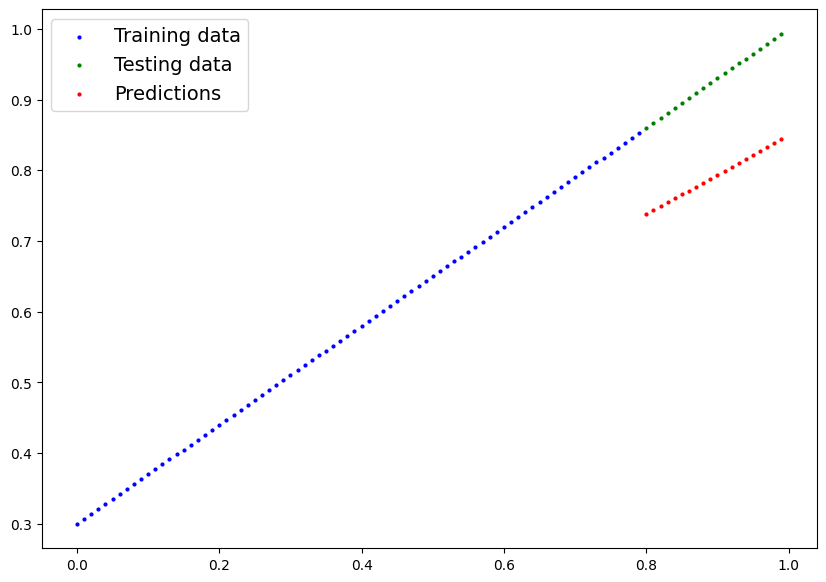

In [65]:
model_2.eval()
with torch.inference_mode():
  y_preds = model_2(X_test_regression)
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu())
b = y_preds[:5] #<------------------------------------------------------------------------------------------------------------------------

# 6: The missing piece: non-linearity

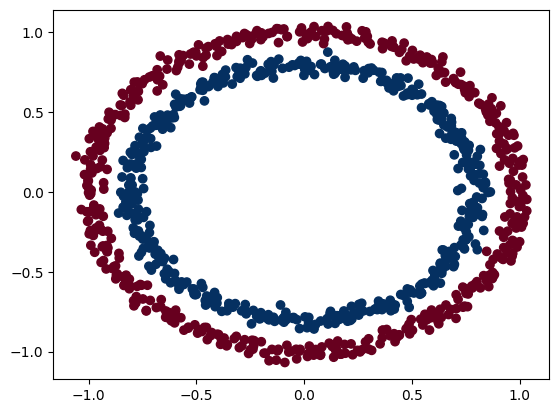

In [66]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

x, y = make_circles(
    n_samples = 1000,
    noise=0.03,
    random_state=42
)

plt.scatter(x[ :, 0 ], x[ :, 1], c=y, cmap=plt.cm.RdBu)
plt.show()

In [67]:
# Convert to tensors and split into train and test sets
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(x).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42
)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

**Building a model with now linear**

In [68]:
class circlesModelv2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_3(self.layer_2(self.relu(self.layer_1(x))))\

model_3 = circlesModelv2().to(device)
model_3


circlesModelv2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [69]:
loos_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(),
                            lr=0.1)

Training model with non-linearlity

In [70]:
torch.manual_seed(42)
epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)


for epoch in range(epochs):

  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loos = loos_fn(y_logits, y_train)
  acc = acuracy(y_pred, y_train)

  optimizer.zero_grad()

  loos.backward()

  optimizer.step()

  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).to(device).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loos = loos_fn(test_logits, y_test)
    test_acc = acuracy(y_pred=test_pred, y_true=y_test)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")



Epoch: 0 | Loss: 0.05068, Accuracy: 50.00% | Test Loss: 0.13566, Test Accuracy: 50.00%
Epoch: 100 | Loss: 0.05068, Accuracy: 52.38% | Test Loss: 0.13566, Test Accuracy: 51.00%
Epoch: 200 | Loss: 0.05068, Accuracy: 58.25% | Test Loss: 0.13566, Test Accuracy: 59.00%
Epoch: 300 | Loss: 0.05068, Accuracy: 53.87% | Test Loss: 0.13566, Test Accuracy: 58.00%
Epoch: 400 | Loss: 0.05068, Accuracy: 53.87% | Test Loss: 0.13566, Test Accuracy: 57.00%
Epoch: 500 | Loss: 0.05068, Accuracy: 53.25% | Test Loss: 0.13566, Test Accuracy: 58.00%
Epoch: 600 | Loss: 0.05068, Accuracy: 59.13% | Test Loss: 0.13566, Test Accuracy: 59.00%
Epoch: 700 | Loss: 0.05068, Accuracy: 71.75% | Test Loss: 0.13566, Test Accuracy: 75.00%
Epoch: 800 | Loss: 0.05068, Accuracy: 85.88% | Test Loss: 0.13566, Test Accuracy: 87.00%
Epoch: 900 | Loss: 0.05068, Accuracy: 94.12% | Test Loss: 0.13566, Test Accuracy: 90.50%


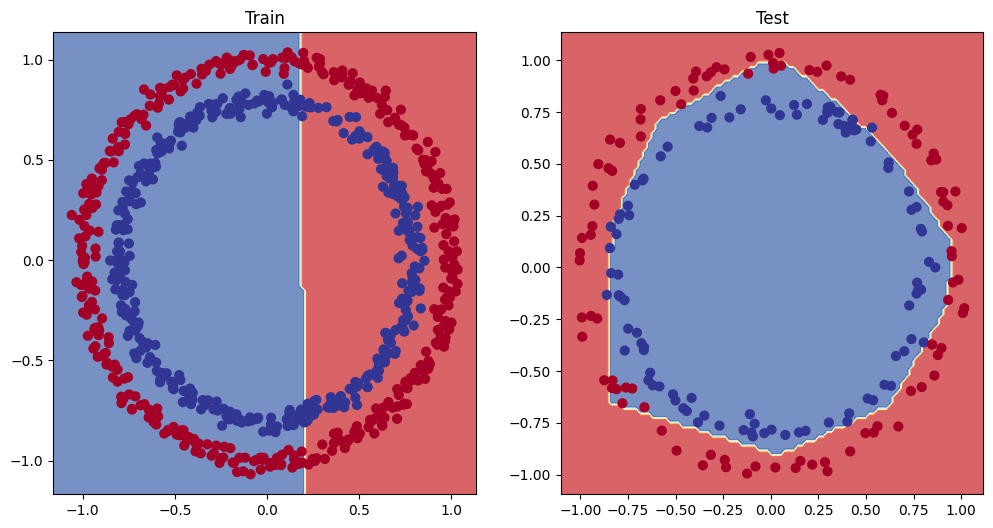

In [71]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3 = has non-linearity

# 7: Multiclass classification

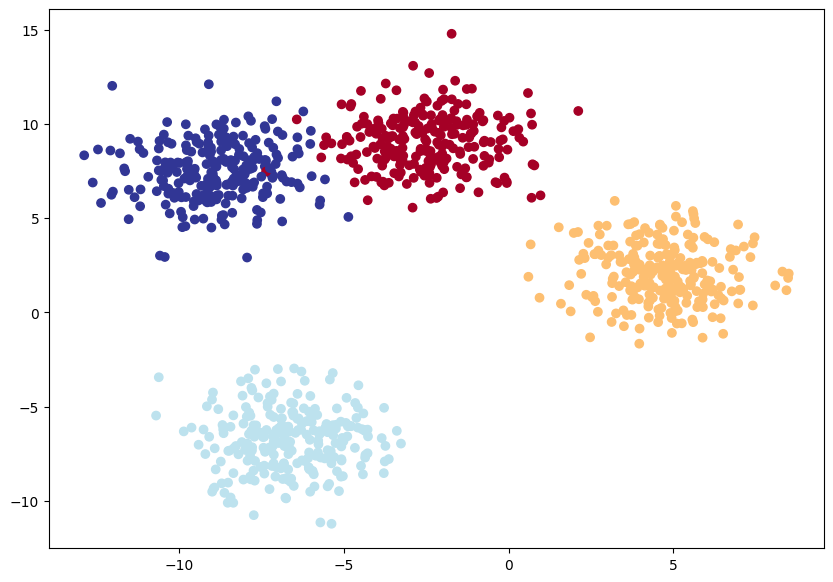

In [72]:

from sklearn.datasets import make_blobs


NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
    n_features=NUM_FEATURES, # X features
    centers=NUM_CLASSES, # y labels
    cluster_std=1.5, # give the clusters a little shake up (try changing this to 1.0, the default)
    random_state=RANDOM_SEED
)

X_blobs = torch.from_numpy(X_blob).type(torch.float)
Y_blobs = torch.from_numpy(y_blob).type(torch.LongTensor) # Use LongTensor for classification labels
X_blobs[:10], Y_blobs[:10]

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
    y_blob,
    test_size=0.2,
    random_state=RANDOM_SEED
)

plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

In [73]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [74]:
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.linear_layer_stack=nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units), # Changed input features to hidden_units
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features), # Changed input features to hidden_units and output features to output_features
    )
  def forward(self, x):
    return self.linear_layer_stack(x)
model_4 = BlobModel(
    input_features=NUM_FEATURES,
    output_features=NUM_CLASSES,
    hidden_units=8
).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [75]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(),
                            lr=0.1)
loss_fn, optimizer

(CrossEntropyLoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.1
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

In [76]:
model_4.eval()
with torch.inference_mode():
  # Convert X_blob_test from numpy.ndarray to torch.Tensor and move to device
  X_blob_test_tensor = torch.from_numpy(X_blob_test).type(torch.float).to(device)
  y_preds = model_4(X_blob_test_tensor)
y_preds[:10]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]], device='cuda:0')

In [77]:
# Make prediction logits with model
# Convert X_blob_test from numpy.ndarray to torch.Tensor and move to device
X_blob_test_tensor = torch.from_numpy(X_blob_test).type(torch.float).to(device)
y_logits = model_4(X_blob_test_tensor)

# Perform softmax calculation on logits across dimension 1 to get prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]], device='cuda:0',
       grad_fn=<SliceBackward0>)
tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]], device='cuda:0',
       grad_fn=<SliceBackward0>)


Traning and Testing loop

In [78]:
torch.manual_seed(42)

# get data ready
# X_blob_train, X_blob_test, y_blob_train, y_blob_test
X_blob_train = torch.from_numpy(X_blob_train).type(torch.float).to(device)
Y_blob_train = torch.from_numpy(y_blob_train).type(torch.LongTensor).to(device)
X_blob_test = torch.from_numpy(X_blob_test).type(torch.float).to(device)
y_blob_test = torch.from_numpy(y_blob_test).type(torch.LongTensor).to(device)

for epoch in range(epochs):
    ### Training
    model_4.train()

    # 1. Forward pass
    y_logits = model_4(X_blob_train) # model outputs raw logits
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels
    # print(y_logits)
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, Y_blob_train)
    acc = acuracy(y_true=Y_blob_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_4(X_blob_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Calculate test loss and accuracy
      test_loss = loss_fn(test_logits, y_blob_test)
      test_acc = acuracy(y_true=y_blob_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.15883, Acc: 40.38% | Test Loss: 1.07554, Test Acc: 48.00%
Epoch: 100 | Loss: 0.03312, Acc: 99.25% | Test Loss: 0.02433, Test Acc: 99.50%
Epoch: 200 | Loss: 0.02657, Acc: 99.25% | Test Loss: 0.01651, Test Acc: 99.50%
Epoch: 300 | Loss: 0.02503, Acc: 99.25% | Test Loss: 0.01440, Test Acc: 99.50%
Epoch: 400 | Loss: 0.02427, Acc: 99.25% | Test Loss: 0.01335, Test Acc: 99.50%
Epoch: 500 | Loss: 0.02377, Acc: 99.25% | Test Loss: 0.01269, Test Acc: 99.50%
Epoch: 600 | Loss: 0.02339, Acc: 99.25% | Test Loss: 0.01218, Test Acc: 99.50%
Epoch: 700 | Loss: 0.02307, Acc: 99.25% | Test Loss: 0.01179, Test Acc: 99.50%
Epoch: 800 | Loss: 0.02279, Acc: 99.25% | Test Loss: 0.01147, Test Acc: 99.50%
Epoch: 900 | Loss: 0.02253, Acc: 99.25% | Test Loss: 0.01120, Test Acc: 99.50%


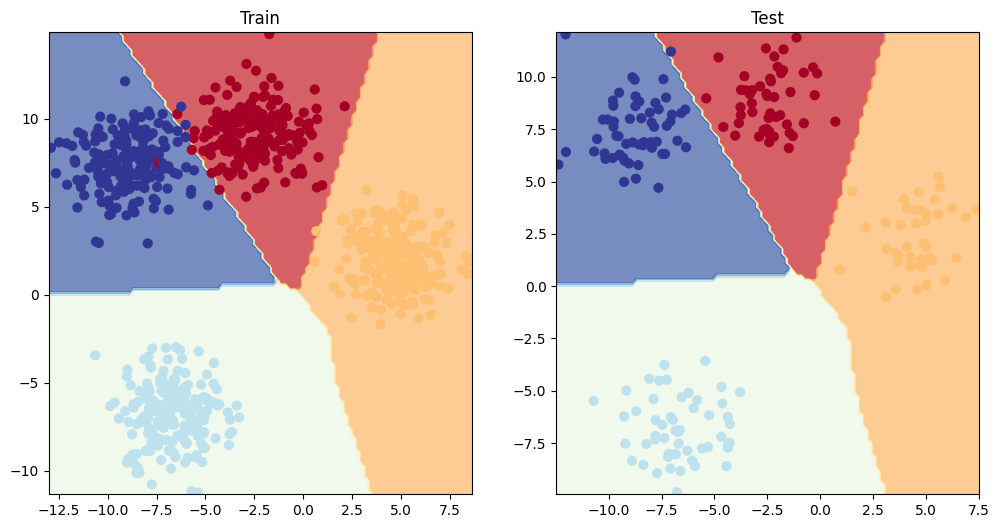

In [79]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, Y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)